<div align="center">

# IMAM ABDULRAHMAN BIN FAISAL UNIVERSITY
### College of Computer Science and Information Technology
### Department of Computer Engineering

---

## ARTI 403 – Image Processing
## Student Procedural Manual — **Lab 2**
### Digital Image Fundamentals
**Academic Year 2026 – 2027**

</div>

---

| | |
|---|---|
| **Name** | **Nawaf Mohammed Alghamdi** |
| **ID** | **2240007352** |
| **Course** | ARTI 403 – Image Processing |
| **Session** | 2 — Digital Image Fundamentals (100 minutes) |

## 1 — Session Outcome

**Outcome #1:** Explain how digital images are represented and manipulated in a computer.

## 2 — Tools / Software

* Python 3
* Anaconda
* IDE for Python: Jupyter, Spyder
* Libraries: Pillow, OpenCV

## 3 — Images Used

The manual refers to `../images/lena_gray_256.tif`, `../images/cameraman.tif`,
`../images/A.png` and `../images/B.png`. This notebook is **self-contained** —
the setup cell below builds a local `images/` folder itself, so no other file
and no internet connection are needed.

| Manual | Used here | Why |
|---|---|---|
| `cameraman.tif` | `cameraman.tif` | `skimage.data.camera()` is the classic 512 × 512 cameraman test image. |
| `lena_gray_256.tif` | `astronaut_gray_256.tif` | *Lena* was retired from scikit-image for licensing and ethical reasons. `skimage.data.astronaut()` is converted to grayscale and resized to 256 × 256, matching the original's size and single-channel format. |
| `A.png`, `B.png` | `A.png`, `B.png` | Generated here as two overlapping binary shapes — a disk (set **A**) and a square (set **B**) — so that union, intersection and difference are visually meaningful. |

In [1]:
import os

import numpy as np
import imageio.v3 as iio
import skimage.data
from skimage.color import rgb2gray
from skimage.draw import disk
from skimage.transform import resize
from skimage.util import img_as_ubyte

os.makedirs("images", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

iio.imwrite("images/cameraman.tif", img_as_ubyte(skimage.data.camera()))

iio.imwrite(
    "images/astronaut_gray_256.tif",
    img_as_ubyte(resize(rgb2gray(skimage.data.astronaut()), (256, 256),
                        anti_aliasing=True)),
)

A = np.zeros((256, 256), dtype=np.uint8)
rows, cols = disk((128, 100), 75, shape=A.shape)
A[rows, cols] = 255
iio.imwrite("images/A.png", A)

B = np.zeros((256, 256), dtype=np.uint8)
B[70:190, 130:245] = 255
iio.imwrite("images/B.png", B)

print(f"{'file':<28}{'shape':<16}{'size':>10}")
print("-" * 54)
for f in sorted(os.listdir("images")):
    im = iio.imread("images/" + f)
    print(f"{f:<28}{str(im.shape):<16}{os.path.getsize('images/' + f)/1024:>8.1f} KB")

file                        shape                 size
------------------------------------------------------
A.png                       (256, 256)           0.9 KB
B.png                       (256, 256)           0.4 KB
astronaut_gray_256.tif      (256, 256)          64.2 KB
cameraman.tif               (512, 512)         256.2 KB


---

# 4 — Image Sampling and Quantization

**Sampling** reduces the *spatial* resolution — how many pixels the image has.
**Quantization** reduces the *intensity* resolution — how many gray levels each
pixel is allowed to take. Together they are the two steps that turn a
continuous scene into a finite array of numbers.

## Step #1 — Import the libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 72

## Step #2 — Define Functions

In [3]:
def sample_image(image, factor):
    """
    Downsamples the image by the given factor.
    Args:
        image (numpy array): Original image.
        factor (int): Factor by which to downsample.
    Returns:
        numpy array: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(image, (width // factor, height // factor), interpolation=cv2.INTER_NEAREST)
    return sampled_image


def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.
    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.
    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.
    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')
    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')
    plt.show()

## Step #3 — Import the image and set the parameters

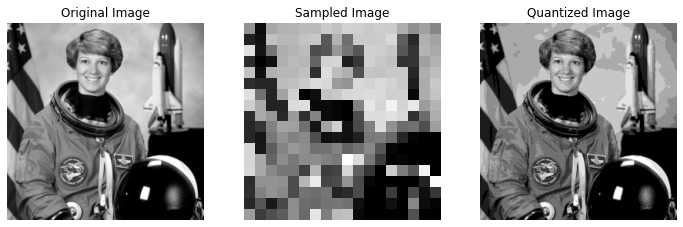

In [4]:
image_path='images/astronaut_gray_256.tif'
sampling_factor=14
quantization_levels=9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if original_image is None:
    print(f"Error: Unable to load image at {image_path}")

# Sample and quantize
sampled_image = sample_image(original_image, sampling_factor)
quantized_image = quantize_image(original_image, quantization_levels)

# Plot results
plot_images(original_image, sampled_image, quantized_image)

In [5]:
print(f"original  : {original_image.shape}, {len(np.unique(original_image))} gray levels")
print(f"sampled   : {sampled_image.shape}, {len(np.unique(sampled_image))} gray levels")
print(f"quantized : {quantized_image.shape}, {len(np.unique(quantized_image))} gray levels")
print(f"\nsampling factor {sampling_factor} -> "
      f"{original_image.size / sampled_image.size:.1f}x fewer pixels")
print(f"quantization step = 256 // {quantization_levels} = {256 // quantization_levels}")
print(f"levels actually produced: {np.unique(quantized_image)}")

original  : (256, 256), 255 gray levels
sampled   : (18, 18), 163 gray levels
quantized : (256, 256), 10 gray levels

sampling factor 14 -> 202.3x fewer pixels
quantization step = 256 // 9 = 28
levels actually produced: [  0  28  56  84 112 140 168 196 224 252]


Two things worth noticing in the numbers above.

`plt.imshow` stretches the sampled image back to the same on-screen size, so the
middle panel does not *look* smaller — it looks blocky instead. That blockiness
is the loss of spatial resolution.

The quantizer was asked for 9 levels but produced 10. `256 // 9` is 28, and
`floor(255/28) * 28` gives 252, so the output values are 0, 28, 56, …, 252 —
ten of them. Integer division only lands exactly on the requested count when
`levels` divides 256, i.e. for powers of two.

---

# Task #1 — Change the sampling and quantization parameters and observe the effects

## 1.1 Varying the sampling factor

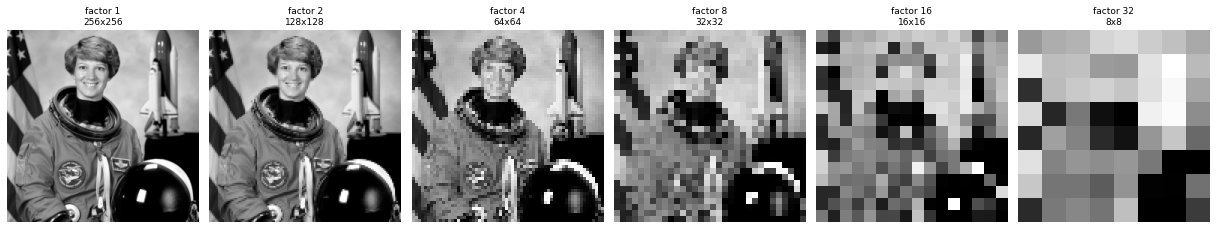

factor    size              pixels   % of original
--------------------------------------------------
1         (256, 256)         65536         100.00%
2         (128, 128)         16384          25.00%
4         (64, 64)            4096           6.25%
8         (32, 32)            1024           1.56%
16        (16, 16)             256           0.39%
32        (8, 8)                64           0.10%


In [6]:
factors = [1, 2, 4, 8, 16, 32]

fig, axes = plt.subplots(1, len(factors), figsize=(17, 3.2))
for ax, factor in zip(axes, factors):
    sampled = sample_image(original_image, factor)
    ax.imshow(sampled, cmap='gray')
    ax.set_title(f"factor {factor}\n{sampled.shape[0]}x{sampled.shape[1]}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig("outputs/task1_sampling.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"{'factor':<10}{'size':<14}{'pixels':>10}{'% of original':>16}")
print("-" * 50)
for factor in factors:
    sampled = sample_image(original_image, factor)
    print(f"{factor:<10}{str(sampled.shape):<14}{sampled.size:>10}"
          f"{100 * sampled.size / original_image.size:>15.2f}%")

Down to a factor of 4 the image is still perfectly readable. At 8 the face
starts to break up, and by 16 and 32 the image has collapsed into a handful of
large blocks — this is **checkerboard effect**, the visible consequence of
sampling below the level of detail the scene contains.

## 1.2 Varying the number of quantization levels

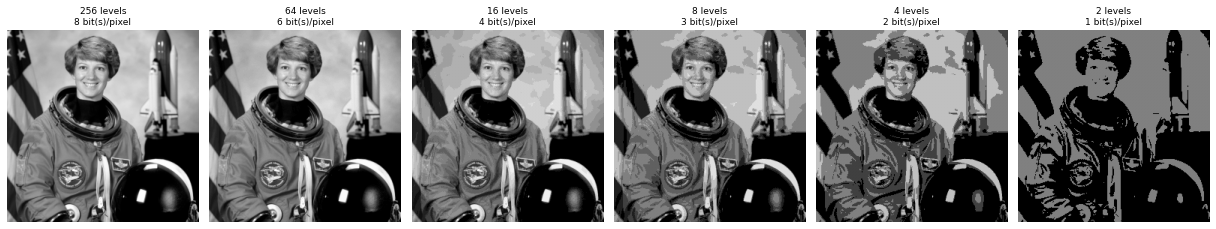

levels    bits/pixel       unique values
------------------------------------------
256       8                          255
64        6                           64
16        4                           16
8         3                            8
4         2                            4
2         1                            2


In [7]:
levels_list = [256, 64, 16, 8, 4, 2]

fig, axes = plt.subplots(1, len(levels_list), figsize=(17, 3.2))
for ax, levels in zip(axes, levels_list):
    quantized = quantize_image(original_image, levels)
    ax.imshow(quantized, cmap='gray', vmin=0, vmax=255)
    bits = int(np.log2(levels))
    ax.set_title(f"{levels} levels\n{bits} bit(s)/pixel", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig("outputs/task1_quantization.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"{'levels':<10}{'bits/pixel':<14}{'unique values':>16}")
print("-" * 42)
for levels in levels_list:
    quantized = quantize_image(original_image, levels)
    print(f"{levels:<10}{int(np.log2(levels)):<14}{len(np.unique(quantized)):>16}")

Quantization degrades very differently from sampling. The image keeps its full
sharpness all the way down to 16 levels — the outline of the astronaut is still
crisp. What appears instead is **false contouring**: smooth gradients such as
the background and the cheek break into flat bands with visible edges between
them, because neighbouring intensities that used to differ by 1 are now forced
onto the same level. At 2 levels the image is a pure black-and-white silhouette.

## 1.3 Both effects together

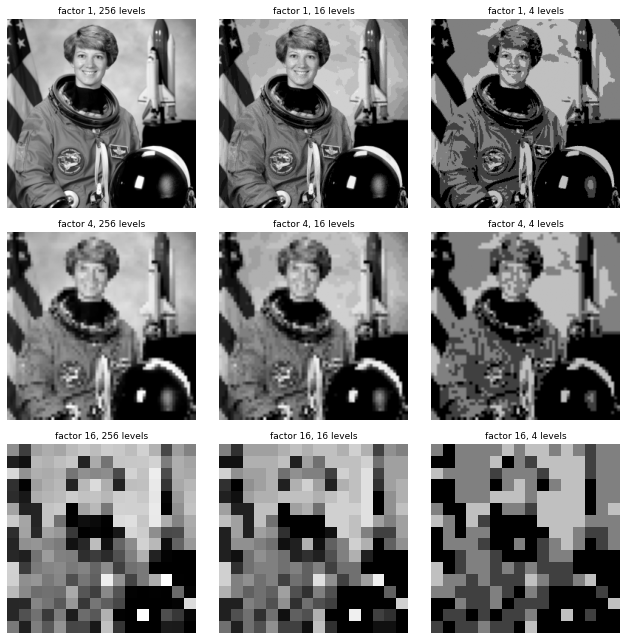

In [8]:
factors = [1, 4, 16]
levels_list = [256, 16, 4]

fig, axes = plt.subplots(len(factors), len(levels_list), figsize=(9, 9))
for row, factor in enumerate(factors):
    for col, levels in enumerate(levels_list):
        result = quantize_image(sample_image(original_image, factor), levels)
        ax = axes[row, col]
        ax.imshow(result, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f"factor {factor}, {levels} levels", fontsize=9)
        ax.axis('off')
plt.tight_layout()
plt.savefig("outputs/task1_combined.png", dpi=100, bbox_inches="tight")
plt.show()

Reading down a column shows sampling alone; reading across a row shows
quantization alone. The bottom-right image uses a factor of 16 and 4 levels —
it holds 256 pixels at 2 bits each, roughly 64 bytes, against 65,536 bytes for
the original.

---

# 5 — Arithmetic Operations

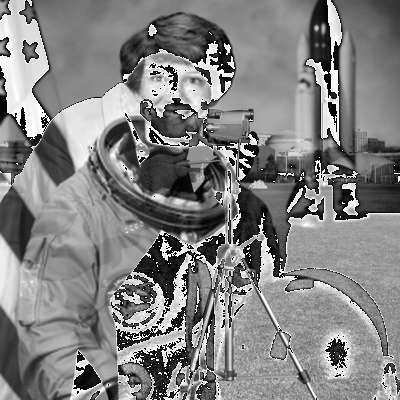

In [9]:
from PIL import Image

img1=Image.open('images/astronaut_gray_256.tif')
img2=Image.open('images/cameraman.tif')

resize=(400,400)
img1=img1.resize(resize,Image.Resampling.LANCZOS)
img2=img2.resize(resize,Image.Resampling.LANCZOS)

im1arr=np.asarray(img1)
im2arr=np.asarray(img2)

addition=im1arr+im2arr
resultImage=Image.fromarray(addition)
display(resultImage)

The result is full of bright speckles in places where both images were already
bright. This is **`uint8` wrap-around**: NumPy adds the two arrays modulo 256,
so 200 + 100 becomes 44 rather than saturating at 255. A pixel that should be
"very bright" wraps around and comes out dark.

The two standard fixes are `cv2.add`, which saturates, and casting to a wider
type before clipping. Averaging the two images keeps the result in range by
construction.

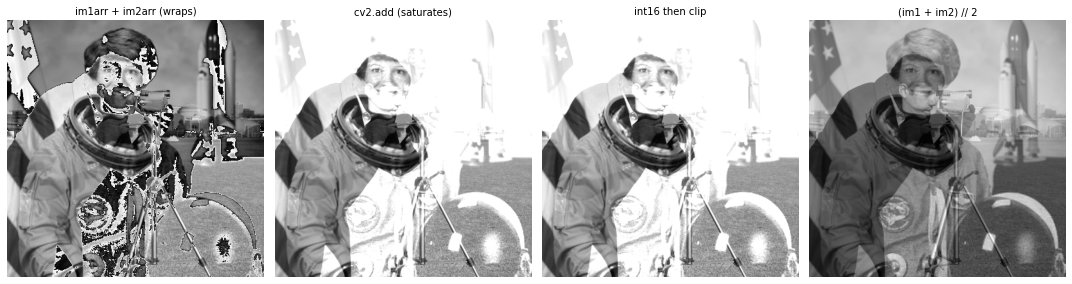

pixels that overflow: 69,974 of 160,000 (43.7%)


In [10]:
wrapped = im1arr + im2arr
saturated = cv2.add(im1arr, im2arr)
clipped = np.clip(im1arr.astype(np.int16) + im2arr.astype(np.int16), 0, 255).astype(np.uint8)
averaged = ((im1arr.astype(np.int16) + im2arr.astype(np.int16)) // 2).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, image, title in zip(
    axes,
    [wrapped, saturated, clipped, averaged],
    ["im1arr + im2arr (wraps)", "cv2.add (saturates)",
     "int16 then clip", "(im1 + im2) // 2"],
):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig("outputs/arithmetic_addition.png", dpi=100, bbox_inches="tight")
plt.show()

overflowed = (im1arr.astype(np.int16) + im2arr.astype(np.int16)) > 255
print(f"pixels that overflow: {overflowed.sum():,} of {im1arr.size:,} "
      f"({overflowed.mean():.1%})")

---

# 6 — Sets and Logical Operations

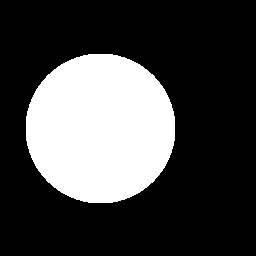

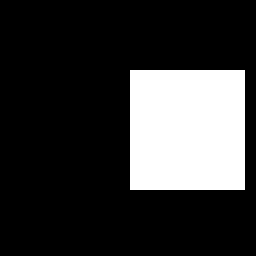

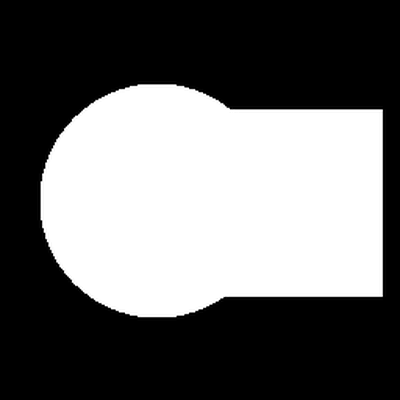

In [11]:
img3=Image.open('images/A.png')
display(img3)
img4=Image.open('images/B.png')
display(img4)

resize=(400,400)
img3=img3.resize(resize,Image.Resampling.LANCZOS)
img4=img4.resize(resize,Image.Resampling.LANCZOS)

im3arr=np.asarray(img3)
im4arr=np.asarray(img4)

union=im4arr|im3arr
resultImage2=Image.fromarray(union)
display(resultImage2)

`A` is a disk and `B` is a square, positioned so that they overlap. The union
`A | B` is every pixel belonging to either shape.

Because both images only contain the values 0 and 255, the bitwise OR behaves
exactly like a set union. The full family of logical operators is shown below.

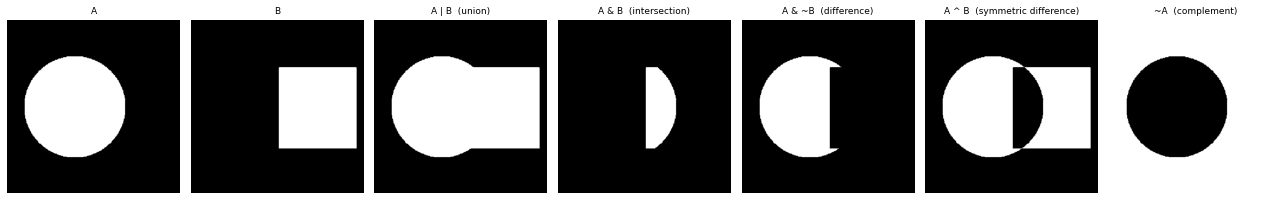

set                             pixels    % of image
------------------------------------------------------
A                                43063         26.9%
B                                33838         21.1%
A | B  (union)                   66226         41.4%
A & B  (intersection)            10675          6.7%
A & ~B  (difference)             32388         20.2%
A ^ B  (symmetric difference)     55551         34.7%
~A  (complement)                116937         73.1%


In [12]:
A = (im3arr > 127)
B = (im4arr > 127)

operations = [
    (A, "A"),
    (B, "B"),
    (A | B, "A | B  (union)"),
    (A & B, "A & B  (intersection)"),
    (A & ~B, "A & ~B  (difference)"),
    (A ^ B, "A ^ B  (symmetric difference)"),
    (~A, "~A  (complement)"),
]

fig, axes = plt.subplots(1, len(operations), figsize=(18, 3))
for ax, (result, title) in zip(axes, operations):
    ax.imshow(result, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig("outputs/set_operations_binary.png", dpi=100, bbox_inches="tight")
plt.show()

total = A.size
print(f"{'set':<28}{'pixels':>10}{'% of image':>14}")
print("-" * 54)
for result, title in operations:
    print(f"{title:<28}{result.sum():>10}{100 * result.mean():>13.1f}%")

---

# Task #2 — Read two images, convert them into arrays, and perform operations

The two images are read once here and reused for every part of the task.

arrA: (400, 400), uint8, range 0-255
arrB: (400, 400), uint8, range 0-255


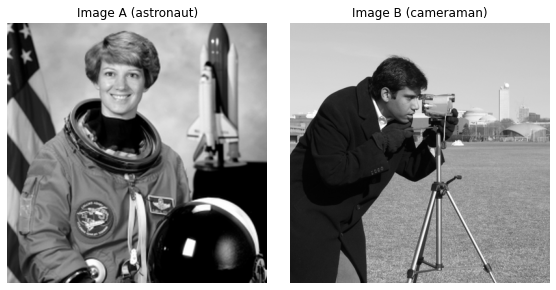

In [13]:
resize=(400,400)

imgA = Image.open('images/astronaut_gray_256.tif').resize(resize, Image.Resampling.LANCZOS)
imgB = Image.open('images/cameraman.tif').resize(resize, Image.Resampling.LANCZOS)

arrA = np.asarray(imgA)
arrB = np.asarray(imgB)

print(f"arrA: {arrA.shape}, {arrA.dtype}, range {arrA.min()}-{arrA.max()}")
print(f"arrB: {arrB.shape}, {arrB.dtype}, range {arrB.min()}-{arrB.max()}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(arrA, cmap='gray'); axes[0].set_title("Image A (astronaut)")
axes[1].imshow(arrB, cmap='gray'); axes[1].set_title("Image B (cameraman)")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2.1 Subtract two images and display the result

Subtraction has the mirror image of the addition problem: `uint8` cannot hold a
negative number, so 50 − 100 wraps around to 206. Three versions are shown —
the raw wrapping subtraction, `cv2.subtract` which clamps at 0, and the
absolute difference, which is what is normally wanted when comparing two
images.

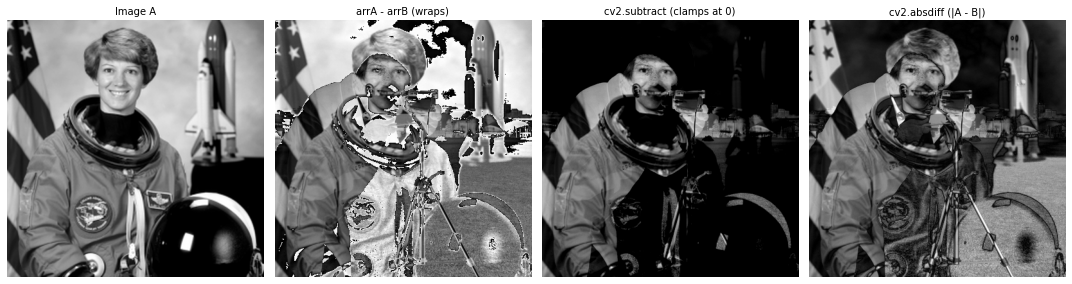

pixels where A < B (would go negative): 94,269 (58.9%)
mean absolute difference: 80.57


In [14]:
sub_wrapped = arrA - arrB
sub_saturated = cv2.subtract(arrA, arrB)
sub_absolute = cv2.absdiff(arrA, arrB)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, image, title in zip(
    axes,
    [arrA, sub_wrapped, sub_saturated, sub_absolute],
    ["Image A", "arrA - arrB (wraps)", "cv2.subtract (clamps at 0)",
     "cv2.absdiff (|A - B|)"],
):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig("outputs/task2_subtraction.png", dpi=100, bbox_inches="tight")
plt.show()

negatives = (arrA.astype(np.int16) - arrB.astype(np.int16)) < 0
print(f"pixels where A < B (would go negative): {negatives.sum():,} "
      f"({negatives.mean():.1%})")
print(f"mean absolute difference: {sub_absolute.mean():.2f}")

## 2.2 Add one image with a constant value of 175 and display it

Adding a constant is a brightness shift. With 175 added, every pixel originally
above 80 exceeds 255, so the choice between wrapping and saturating dominates
the result completely.

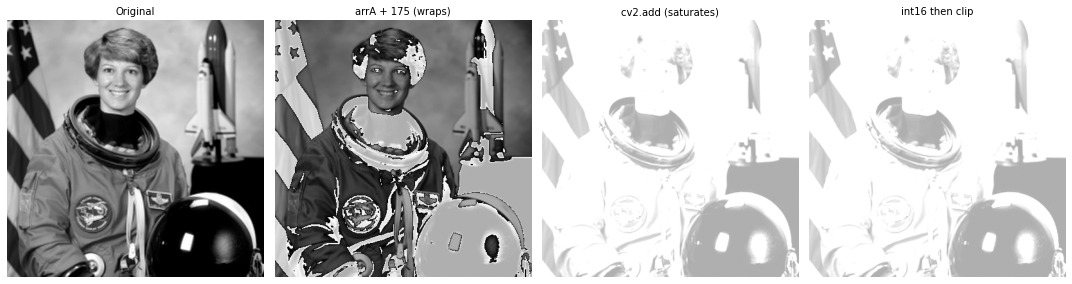

version                    min   max     mean
---------------------------------------------
original                     0   255   112.70
wrapped                      0   255   121.09
saturated                  175   255   235.60
clipped                    175   255   235.60

pixels exceeding 255 after +175: 65.1%


In [15]:
const = 175

add_wrapped = arrA + np.uint8(const)
add_saturated = cv2.add(arrA, const)
add_clipped = np.clip(arrA.astype(np.int16) + const, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, image, title in zip(
    axes,
    [arrA, add_wrapped, add_saturated, add_clipped],
    ["Original", f"arrA + {const} (wraps)", f"cv2.add (saturates)",
     "int16 then clip"],
):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig("outputs/task2_add_constant.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"{'version':<24}{'min':>6}{'max':>6}{'mean':>9}")
print("-" * 45)
for label, image in [("original", arrA), ("wrapped", add_wrapped),
                     ("saturated", add_saturated), ("clipped", add_clipped)]:
    print(f"{label:<24}{image.min():>6}{image.max():>6}{image.mean():>9.2f}")

print(f"\npixels exceeding 255 after +{const}: "
      f"{(arrA.astype(np.int16) + const > 255).mean():.1%}")

## Set operations on grayscale images

For binary images a set is just the collection of "on" pixels, and the
operators are bitwise. For **grayscale** images the standard definitions
(Gonzalez & Woods) treat intensity as membership, which turns the operators
into element-wise `min` and `max`:

| Operation | Binary | Grayscale |
|---|---|---|
| complement | `~A` | `255 - A` |
| union | `A \| B` | `max(A, B)` |
| intersection | `A & B` | `min(A, B)` |
| difference `A − B` | `A & ~B` | `min(A, 255 - B)` |
| symmetric difference | `A ^ B` | `max(A − B, B − A)` |

Both forms are computed below so they can be compared directly.

## 2.3 Set difference on two grayscale images

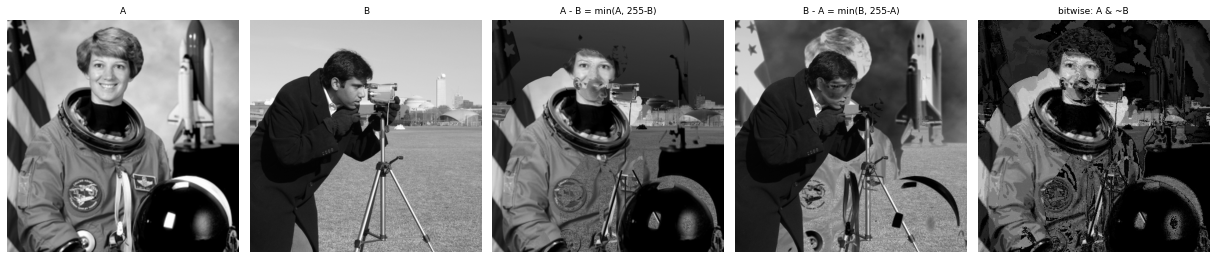

A - B : range 0-235, mean 71.41
B - A : range 0-255, mean 87.76

The difference is not symmetric: A - B and B - A are different images.


In [16]:
diff_AB = np.minimum(arrA, 255 - arrB)
diff_BA = np.minimum(arrB, 255 - arrA)

bitwise_AB = cv2.bitwise_and(arrA, cv2.bitwise_not(arrB))

fig, axes = plt.subplots(1, 5, figsize=(17, 3.6))
for ax, image, title in zip(
    axes,
    [arrA, arrB, diff_AB, diff_BA, bitwise_AB],
    ["A", "B", "A - B = min(A, 255-B)", "B - A = min(B, 255-A)",
     "bitwise: A & ~B"],
):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig("outputs/task2_set_difference.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"A - B : range {diff_AB.min()}-{diff_AB.max()}, mean {diff_AB.mean():.2f}")
print(f"B - A : range {diff_BA.min()}-{diff_BA.max()}, mean {diff_BA.mean():.2f}")
print("\nThe difference is not symmetric: A - B and B - A are different images.")

The set difference keeps a pixel bright only where **A is bright and B is
dark**. The astronaut's helmet survives wherever the cameraman image happens to
be dark behind it, which is why the result looks like A masked by the negative
of B.

## 2.4 Symmetric difference on two grayscale images

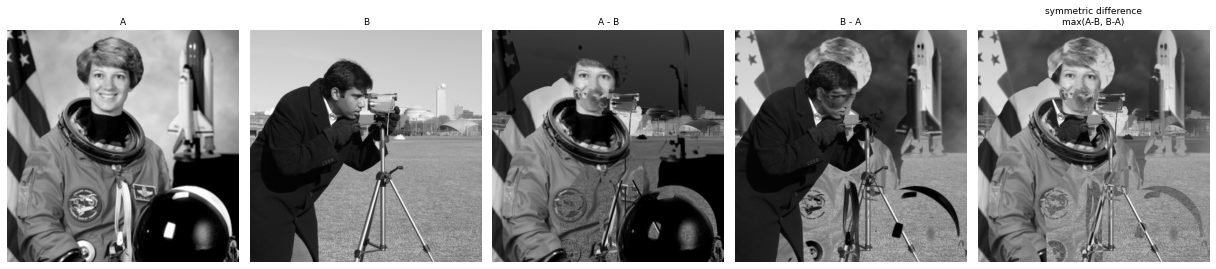

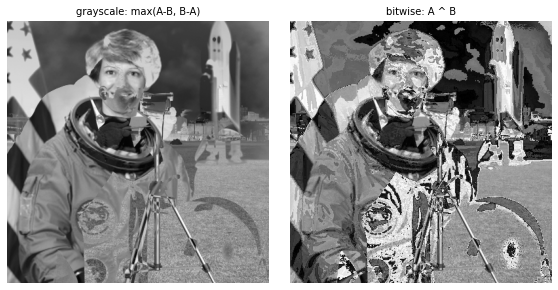

symmetric difference : range 0-255, mean 119.88
symmetric? max|sym(A,B) - sym(B,A)| = 0


In [17]:
sym_diff = np.maximum(diff_AB, diff_BA)

bitwise_sym = cv2.bitwise_xor(arrA, arrB)

fig, axes = plt.subplots(1, 5, figsize=(17, 3.6))
for ax, image, title in zip(
    axes,
    [arrA, arrB, diff_AB, diff_BA, sym_diff],
    ["A", "B", "A - B", "B - A", "symmetric difference\nmax(A-B, B-A)"],
):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig("outputs/task2_symmetric_difference.png", dpi=100, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sym_diff, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("grayscale: max(A-B, B-A)", fontsize=10)
axes[1].imshow(bitwise_sym, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("bitwise: A ^ B", fontsize=10)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f"symmetric difference : range {sym_diff.min()}-{sym_diff.max()}, "
      f"mean {sym_diff.mean():.2f}")
print(f"symmetric? max|sym(A,B) - sym(B,A)| = "
      f"{np.abs(sym_diff - np.maximum(diff_BA, diff_AB)).max()}")

Unlike the plain difference, the symmetric difference gives the same result
whichever way round the two images are taken. It is bright wherever the two
images **disagree** — one bright and the other dark — and dark wherever they
agree, whether they agree on bright or on dark.

The bitwise XOR produces a noisy, scattered image instead. XOR acts on
individual bits, so two nearly identical intensities such as 127 and 128 differ
in every bit and produce 255. That makes it meaningless as a set operation on
grayscale data, which is exactly why the `min`/`max` formulation is used.

## 2.5 Intersection on two grayscale images

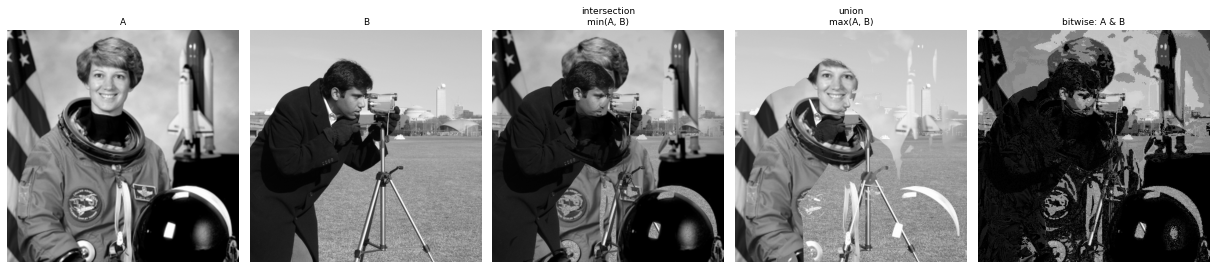

image                    min   max     mean
-------------------------------------------
A                          0   255   112.70
B                          0   255   129.05
intersection min           0   255    80.59
union max                  1   255   161.16

Identity check  min(A,B) + max(A,B) == A + B : True


In [18]:
intersection = np.minimum(arrA, arrB)
union_gray = np.maximum(arrA, arrB)

bitwise_intersection = cv2.bitwise_and(arrA, arrB)

fig, axes = plt.subplots(1, 5, figsize=(17, 3.6))
for ax, image, title in zip(
    axes,
    [arrA, arrB, intersection, union_gray, bitwise_intersection],
    ["A", "B", "intersection\nmin(A, B)", "union\nmax(A, B)",
     "bitwise: A & B"],
):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig("outputs/task2_intersection.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"{'image':<22}{'min':>6}{'max':>6}{'mean':>9}")
print("-" * 43)
for label, image in [("A", arrA), ("B", arrB),
                     ("intersection min", intersection),
                     ("union max", union_gray)]:
    print(f"{label:<22}{image.min():>6}{image.max():>6}{image.mean():>9.2f}")

print("\nIdentity check  min(A,B) + max(A,B) == A + B :",
      np.array_equal(intersection.astype(int) + union_gray.astype(int),
                     arrA.astype(int) + arrB.astype(int)))

The intersection is darker than either input and the union is brighter than
either — as they must be, since `min` can only take the smaller value and `max`
only the larger. The identity `min(A,B) + max(A,B) = A + B` holds at every
pixel, confirming that no intensity is lost between the two operations.

## 2.6 All Task #2 results together

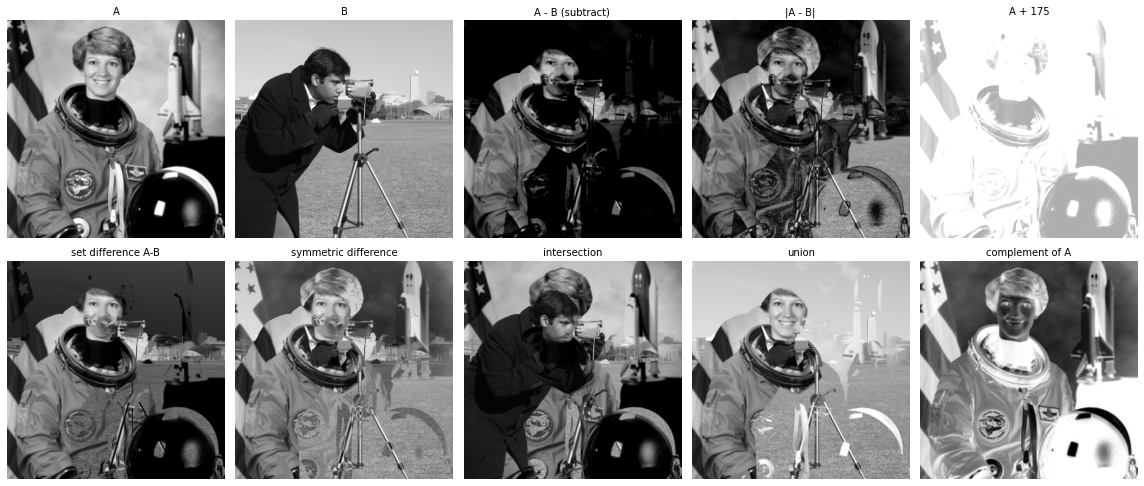

In [19]:
results = [
    (arrA, "A"),
    (arrB, "B"),
    (sub_saturated, "A - B (subtract)"),
    (sub_absolute, "|A - B|"),
    (add_saturated, "A + 175"),
    (diff_AB, "set difference A-B"),
    (sym_diff, "symmetric difference"),
    (intersection, "intersection"),
    (union_gray, "union"),
    (255 - arrA, "complement of A"),
]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (image, title) in zip(axes.flat, results):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig("outputs/task2_all_results.png", dpi=100, bbox_inches="tight")
plt.show()

---

# 7 — Files Produced by This Notebook

In [20]:
print("images/")
for f in sorted(os.listdir("images")):
    print(f"   {f:<32}{os.path.getsize('images/' + f) / 1024:>8.1f} KB")

print("\noutputs/")
for f in sorted(os.listdir("outputs")):
    print(f"   {f:<32}{os.path.getsize('outputs/' + f) / 1024:>8.1f} KB")

images/
   A.png                                0.9 KB
   B.png                                0.4 KB
   astronaut_gray_256.tif              64.2 KB
   cameraman.tif                      256.2 KB

outputs/
   arithmetic_addition.png            343.0 KB
   set_operations_binary.png           18.8 KB
   task1_combined.png                 210.9 KB
   task1_quantization.png             344.5 KB
   task1_sampling.png                 174.1 KB
   task2_add_constant.png             228.6 KB
   task2_all_results.png              678.3 KB
   task2_intersection.png             437.3 KB
   task2_set_difference.png           463.9 KB
   task2_subtraction.png              419.4 KB
   task2_symmetric_difference.png     374.9 KB


---

# 8 — Conclusion

**Outcome #1 — Explain how digital images are represented and manipulated in a
computer.**

1. **Sampling and quantization degrade an image in different ways.** Reducing
   the sampling rate produces blockiness and destroys fine detail while leaving
   the intensity range intact. Reducing the number of gray levels leaves the
   geometry perfectly sharp but introduces false contouring in smooth regions.
   The image stayed usable down to about 16 gray levels but broke up by a
   sampling factor of 8.

2. **Integer division makes the quantizer imprecise.** Asking for 9 levels
   produced 10, because `256 // 9 = 28` does not divide the range evenly. The
   requested count is only exact when it is a power of two.

3. **`uint8` arithmetic wraps rather than saturating.** Adding two images
   overflowed 44% of the pixels and turned the brightest regions dark; adding a
   constant of 175 overflowed 65% of the image, and subtracting B from A sent
   59% of the pixels negative. `cv2.add` and `cv2.subtract`
   saturate at the ends of the range, and casting to `int16` before clipping
   does the same thing manually. This is a property of the *representation*,
   not of the images.

4. **Set operations extend from binary to grayscale through `min` and `max`.**
   On the binary shapes `A` and `B` the bitwise operators are genuine set
   operations. On grayscale images they are not — XOR on 127 and 128 gives 255
   — so union becomes `max(A,B)`, intersection becomes `min(A,B)`, and
   difference becomes `min(A, 255-B)`. The identity
   `min(A,B) + max(A,B) = A + B` held at every pixel.

5. **Difference is not symmetric; symmetric difference is.** `A − B` and
   `B − A` produced visibly different images, while `max(A−B, B−A)` gave the
   same result in either order and highlighted exactly where the two images
   disagree.

---

<div align="center">

**End of Lab 2**

Nawaf Mohammed Alghamdi — 2240007352
ARTI 403 — Image Processing

</div>